# 高维单位球中的体积集中与函数拟合

本记录研究在 100 维单位球上按体积均匀采样、拟合 f(x)=||x||² 时，训练误差与不同半径区域的预测误差之间的差异。

参考：《深度学习导论》，所用 PDF 第 64—65 页、图 2.2。正式书目信息与版次待核实。本实现非教材官方代码。

**AI 披露**：实现与文档整理使用 OpenAI Codex，见 AI_USAGE.md。保存输出来自参考运行；公开整理版本已在参考环境完整重跑，数值结果与参考记录一致；尚未在全新环境或其他操作系统验证。


## 环境与随机性

NumPy 和 PyTorch 随机种子为 42。网络在 CPU 上运行，使用四线程。运行依赖与方法边界见 README.md。

In [1]:
# 运行环境与随机种子。
from pathlib import Path
import os
# Anaconda 的 NumPy 使用 MKL；先让 MKL 使用顺序计算，避免与 PyTorch 的 OpenMP 冲突。
# PyTorch 自身仍使用下面设置的四个线程。这不放宽重复运行库检查。
os.environ['MKL_THREADING_LAYER'] = 'SEQUENTIAL'
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

PROJECT = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd()
OUT = PROJECT / 'results' / 'latest'
OUT.mkdir(parents=True, exist_ok=True)
torch.set_num_threads(4)
torch.manual_seed(42)
rng = np.random.default_rng(42)
D, N, WIDTH = 100, 10000, 512
print('Python / PyTorch ready. PyTorch:', torch.__version__, flush=True)


Python / PyTorch ready. PyTorch: 2.14.0+cpu


## 训练分布

训练输入 X∈R^(10000×100)，标签 y_i=Σ_j X_ij²。使用标准正态向量归一化生成均匀方向，半径取 R=U^(1/d)。由 P(R≤r)=r^d 可知该采样符合球内体积均匀分布。

以 E[R²]=d/(d+2) 和区域样本数检查采样结果。

In [2]:
# 训练数据：球内体积均匀采样与平方和标签。
def sample_ball(n, d, generator):
    z = generator.normal(size=(n, d))
    direction = z / np.linalg.norm(z, axis=1, keepdims=True)
    radius = generator.random((n, 1)) ** (1 / d)
    return (direction * radius).astype(np.float32)

X = sample_ball(N, D, rng)
y = np.sum(X**2, axis=1, keepdims=True)
r = np.linalg.norm(X, axis=1)
assert X.shape == (N, D) and y.shape == (N, 1)
assert np.all(r <= 1 + 1e-6)
assert abs(y.mean() - D / (D + 2)) < 0.002
print('Data shape:', X.shape, 'Labels:', y.shape, flush=True)
print('Radius minimum / mean / maximum:', r.min(), r.mean(), r.max(), flush=True)
print('Count below radius 0.9 / 0.95:', (r < .9).sum(), (r < .95).sum(), flush=True)


Data shape: (10000, 100) Labels: (10000, 1)
Radius minimum / mean / maximum: 0.90856767 0.9901758 0.9999999
Count below radius 0.9 / 0.95: 0 67


## 数据分布

绘制训练样本半径及标签分布，观察其在球面附近的集中程度。

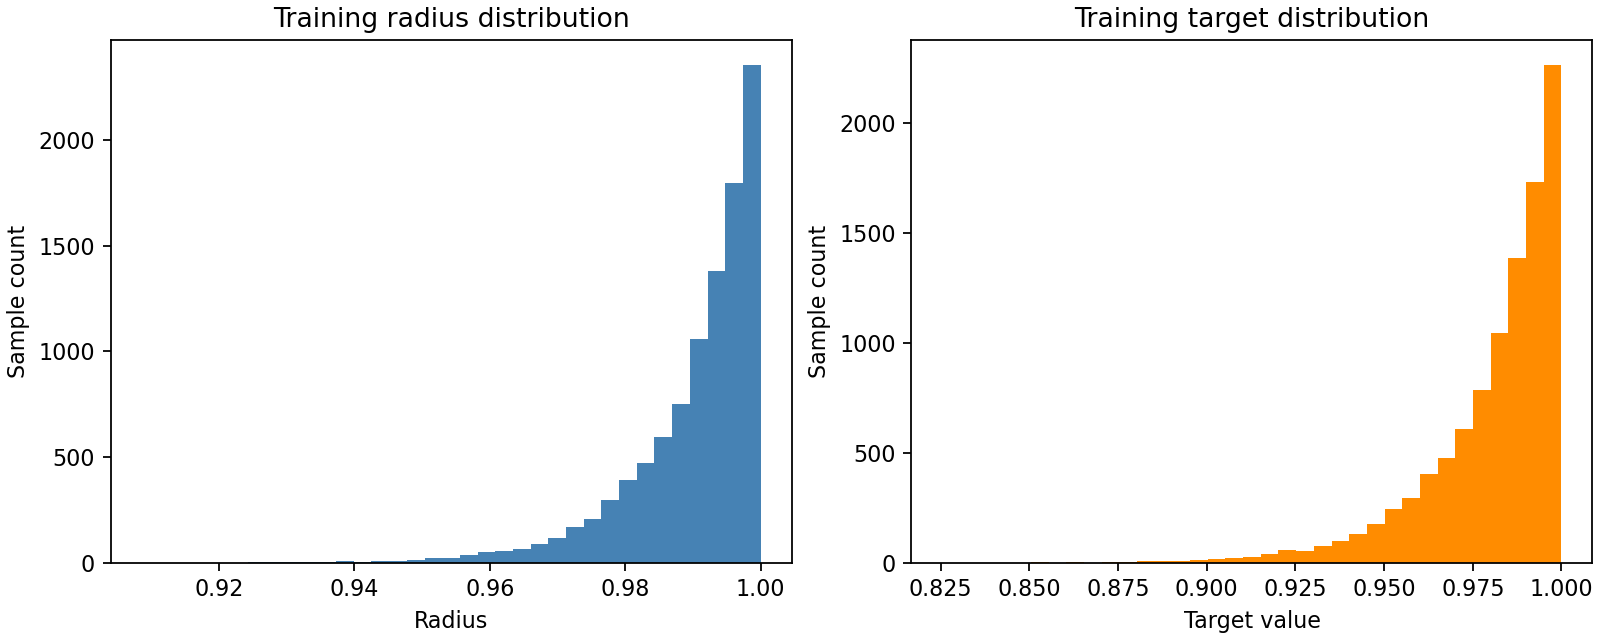

In [3]:
# 训练半径和标签分布。
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].hist(r, bins=35, color='steelblue')
axes[0].set(xlabel='Radius', ylabel='Sample count', title='Training radius distribution')
axes[1].hist(y[:, 0], bins=35, color='darkorange')
axes[1].set(xlabel='Target value', ylabel='Sample count', title='Training target distribution')
fig.savefig(OUT / 'training_data.png', dpi=160)
plt.show()
plt.close(fig)


## 模型

网络采用 100→512→1 两个仿射层，中间为 ReLU 激活；总可训练参数 52225。输入为原始坐标，不额外提供半径或平方和特征。

层数按带参数的仿射层计算。宽度及具体实现是本复刻的补充设置。

In [4]:
# 模型结构与初始化。
train_x, train_y = torch.from_numpy(X), torch.from_numpy(y)
model = nn.Sequential(nn.Linear(D, WIDTH), nn.ReLU(), nn.Linear(WIDTH, 1))
loss_fn = nn.MSELoss()
print(model, flush=True)
print('Trainable parameters:', sum(p.numel() for p in model.parameters()), flush=True)
with torch.no_grad():
    initial_mse = loss_fn(model(train_x), train_y).item()
print('Before training MSE:', initial_mse, flush=True)


Sequential(
  (0): Linear(in_features=100, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=1, bias=True)
)
Trainable parameters: 52225
Before training MSE: 0.8959997892379761


## 优化

目标为全训练集 MSE。采用 Adam，初始学习率 0.001，每 10 次更新检查训练损失；ReduceLROnPlateau 在持续不改善时降低学习率。最多 6000 次更新，达到 MSE<1e-6 后停止，返回训练检查点中损失最低的状态。

所有停止及检查点选择仅依据训练损失。

In [5]:
# 全批量优化；仅依据训练损失停止。
TARGET = 1e-6
MAX_STEPS = 6000
history = []
start = time.perf_counter()
best_mse = initial_mse
best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=20, min_lr=1e-5)
for step in range(1, MAX_STEPS + 1):
    optimizer.zero_grad()
    prediction = model(train_x)
    loss = loss_fn(prediction, train_y)
    loss.backward()
    optimizer.step()
    if step % 10 == 0:
        with torch.no_grad():
            mse = loss_fn(model(train_x), train_y).item()
        if not np.isfinite(mse):
            raise RuntimeError('Non-finite training loss')
        scheduler.step(mse)
        history.append({'stage':'Adam', 'step':step, 'mse':mse, 'lr':optimizer.param_groups[0]['lr']})
        if mse < best_mse:
            best_mse = mse
            best_state = {k:v.detach().clone() for k,v in model.state_dict().items()}
        if step % 100 == 0 or mse < TARGET:
            print(f'Step {step}: training MSE={mse:.8g}; elapsed={time.perf_counter()-start:.1f}s', flush=True)
        if step % 500 == 0:
            torch.save(best_state, OUT / 'training_checkpoint.pt')
        if mse < TARGET:
            break
model.load_state_dict(best_state)
model.eval()
training_seconds = time.perf_counter() - start
with torch.no_grad():
    train_mse = loss_fn(model(train_x), train_y).item()
print('FINAL TRAIN MSE:', train_mse, 'target reached:', train_mse < TARGET, flush=True)
if train_mse >= TARGET:
    print('Threshold NOT reached. Results describe this run only.', flush=True)


Step 100: training MSE=0.00057397893; elapsed=6.4s
Step 200: training MSE=0.00041695681; elapsed=11.3s
Step 300: training MSE=0.00031915194; elapsed=16.6s
Step 400: training MSE=0.00024702519; elapsed=22.2s
Step 500: training MSE=0.00019434454; elapsed=27.2s
Step 600: training MSE=0.00015536956; elapsed=32.8s
Step 700: training MSE=0.00012573152; elapsed=38.1s
Step 800: training MSE=0.00010277039; elapsed=43.4s
Step 900: training MSE=8.4680141e-05; elapsed=48.3s
Step 1000: training MSE=7.0080445e-05; elapsed=53.4s
Step 1100: training MSE=5.814914e-05; elapsed=59.0s
Step 1200: training MSE=4.8301034e-05; elapsed=64.1s
Step 1300: training MSE=4.0195715e-05; elapsed=69.2s
Step 1400: training MSE=3.3475899e-05; elapsed=74.5s
Step 1500: training MSE=2.7879125e-05; elapsed=78.8s
Step 1600: training MSE=2.3192659e-05; elapsed=83.3s
Step 1700: training MSE=1.9282666e-05; elapsed=87.9s
Step 1800: training MSE=1.6011889e-05; elapsed=93.2s
Step 1900: training MSE=1.3253954e-05; elapsed=98.2s
Step

## 评估

- 轴向切片：x=(t,0,…,0)，t∈[-1,1]，500 个点，比较预测与 t²。
- 径向评估：21 个半径，各在球面均匀采样 1000 个点，以 r² 为真值计算 MAE；r=0 时退化为原点。
- 同分布评估：独立采样 10000 个体积均匀测试点，分别报告 MSE 和 MAE。

测试样本不参与参数更新与停止判断。

{
  "initial_mse": 0.8959997892379761,
  "training_mse": 9.995774234994315e-07,
  "threshold_reached": true,
  "iid_test_mse": 0.0004581458051688969,
  "iid_test_mae": 0.01675691083073616,
  "origin_prediction": 0.6966897249221802,
  "radius_0_5_mae": 0.525127371430397,
  "radius_1_mae": 0.018697978138923644,
  "axis_left_prediction": 1.0060776472091675,
  "axis_right_prediction": 0.9721882343292236,
  "training_seconds": 158.63871549999976
}


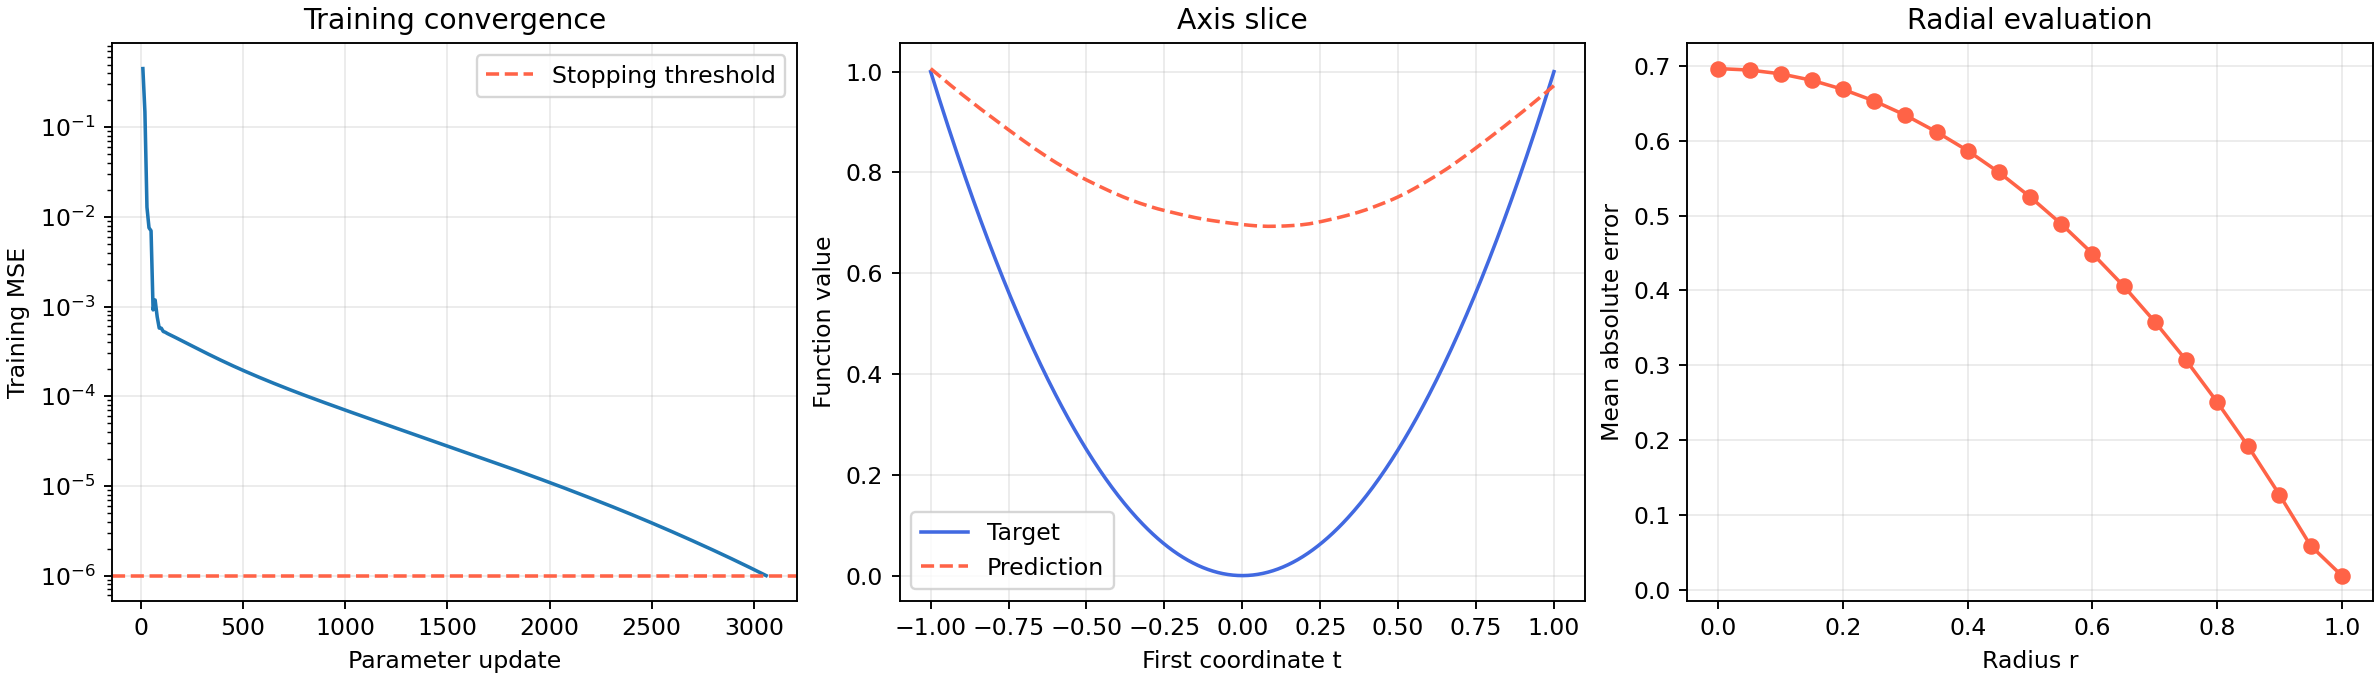

In [6]:
# 独立评估。
def predict(a):
    with torch.no_grad():
        return model(torch.from_numpy(a.astype(np.float32))).numpy().reshape(-1)

# 轴向切片评估：500 个点。
t = np.linspace(-1, 1, 500, dtype=np.float32)
axis_x = np.zeros((500, D), dtype=np.float32)
axis_x[:, 0] = t
axis_pred = predict(axis_x)

# 径向评估：每个半径 1000 个球面点，计算 MAE。
test_rng = np.random.default_rng(1042)
radii = np.linspace(0, 1, 21)
radial_mae = []
for radius in radii:
    z = test_rng.normal(size=(1000, D))
    sphere = radius * z / np.linalg.norm(z, axis=1, keepdims=True)
    radial_mae.append(float(np.mean(np.abs(predict(sphere) - radius**2))))

# 独立同分布测试集。
test_x = sample_ball(10000, D, test_rng)
test_y = np.sum(test_x**2, axis=1)
test_prediction = predict(test_x)
metrics = {
    'initial_mse': initial_mse, 'training_mse': train_mse,
    'threshold_reached': bool(train_mse < TARGET),
    'iid_test_mse': float(np.mean((test_prediction-test_y)**2)),
    'iid_test_mae': float(np.mean(np.abs(test_prediction-test_y))),
    'origin_prediction': float(predict(np.zeros((1,D), dtype=np.float32))[0]),
    'radius_0_5_mae': radial_mae[10], 'radius_1_mae': radial_mae[-1],
    'axis_left_prediction': float(axis_pred[0]),
    'axis_right_prediction': float(axis_pred[-1]),
    'training_seconds': training_seconds,
}
print(json.dumps(metrics, indent=2), flush=True)
fig, ax = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
ax[0].semilogy([h['step'] for h in history], [h['mse'] for h in history])
ax[0].axhline(TARGET, color='tomato', linestyle='--', label='Stopping threshold')
ax[0].set(xlabel='Parameter update', ylabel='Training MSE', title='Training convergence')
ax[0].legend()
ax[1].plot(t, t*t, 'b-', label='Target')
ax[1].plot(t, axis_pred, 'r--', label='Prediction')
ax[1].set(xlabel='First coordinate', ylabel='Function value', title='Axis slice')
ax[1].legend()
ax[2].plot(radii, radial_mae, 'o-', color='tomato')
ax[2].set(xlabel='Radius', ylabel='Mean absolute error', title='Radial evaluation')
for a in ax: a.grid(alpha=.25)
fig.savefig(OUT / 'network_results.png', dpi=170)
plt.show()
plt.close(fig)


## 结果归档与解释边界

输出包括运行参数、指标、训练历史、评估数组和模型参数。当前运行写入 results/latest，发布的参考结果位于 results/reference。

参考运行显示：达到训练阈值后，原点预测仍显著偏离真值，且内部径向误差高于球面附近误差。同分布测试 MSE 高于训练 MSE，说明仍存在训练与测试的差距。

这是特定采样、网络、优化与种子下的单次结果；体积集中并不唯一决定具体函数曲线，也不意味着所有模型必然在内部失败。

In [7]:
# 归档指标、参数与原始评估数据。
config = {'d': D, 'n': N, 'width': WIDTH, 'seed':42, 'loss':'MSE',
          'training':'Full batch Adam, initial lr=0.001, halve lr after 21 non-improving checkpoints, max 6000 steps',
          'target':TARGET, 'torch':str(torch.__version__), 'numpy':np.__version__,
          'device':'cpu', 'threads':4}
(OUT / 'metrics.json').write_text(json.dumps({'config':config, 'metrics':metrics}, indent=2), encoding='utf-8')
(OUT / 'training_history.json').write_text(json.dumps(history, indent=2), encoding='utf-8')
np.savez(OUT / 'evaluation_data.npz', t=t, axis_prediction=axis_pred, radii=radii, radial_mae=radial_mae)
torch.save(model.state_dict(), OUT / 'model_state.pt')
print('Saved results to', OUT, flush=True)
